# Time Rabi: load saved arrays Ã¢â€ â€™ plot Ã¢â€ â€™ fit



This notebook is analysis-only:

- Load the saved `data.json` + `arrays.npz` (DataHandler format)

- Plot the raw arrays and normalized signal

- Fit the oscillation


## 1) Imports + locate NV2_array


In [13]:
from __future__ import annotations
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

def find_workspace_root(start: Path) -> Path:
    start = start.resolve()
    for p in [start, *start.parents]:
        if (p / 'experiment-main').exists():
            return p
    raise RuntimeError('Could not find workspace root containing experiment-main')

WORKSPACE = find_workspace_root(Path.cwd())
NV2 = (WORKSPACE / "qua-libs/Quantum-Control-Applications/Optically addressable spin qubits/NV2_array_sprout").resolve()
sys.path.insert(0, str(WORKSPACE / 'experiment-main'))
from qua_tools_nv2.dataset import DatasetReader
from qua_tools_nv2.nv2_fits import Fitter

CC_NS = 4.0

## 2) Load saved arrays


In [14]:
reader = DatasetReader(nv_root=NV2)
DATA_ROOT = reader.data_root

EXPERIMENT_TAG = 'time_rabi'  # matches dataset folder names like '#17_time_rabi_155155'

# Choose a specific dataset folder or leave None for "latest":
#   DATASET = None
#   DATASET = r'2025-12-31\#17_time_rabi_155155'  # relative to Data/
#   DATASET = r'C:\\...\\NV2_array\\Data\\2025-12-31\\#17_time_rabi_155155'  # absolute
DATASET = None

def find_latest_by_tag(tag: str) -> Path:
    candidates = [p.parent for p in DATA_ROOT.rglob('data.json') if p.is_file() and tag in p.parent.name.lower()]
    if not candidates:
        raise FileNotFoundError(f"No datasets matching tag {tag!r} under {DATA_ROOT}")
    candidates.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    return candidates[0]

ds_folder = find_latest_by_tag(EXPERIMENT_TAG) if DATASET is None else reader.resolve_dataset(DATASET).folder
ds = reader.resolve_dataset(ds_folder)
data = reader.load(ds)

# 06_time_rabi.py saves 't_vec'; 06b_time_rabi_SPAD.py saves 'pulse_durations' — both in clock cycles
t_vec = np.asarray(data.get('t_vec') or data['pulse_durations'], dtype=float)
counts_data = np.asarray(data['counts_data'], dtype=float)
counts_ref_data = np.asarray(data['counts_ref_data'], dtype=float)

cfg = data.get('config') or {}
pulses = cfg.get('pulses') or {}
readout_len_ns = float(pulses['readout_pulse_2']['length'])  # meas_len_2
meas_len_s = readout_len_ns * 1e-9

t_ns = t_vec * CC_NS

signal_kcps = counts_data / 1000.0 / meas_len_s
ref_kcps = counts_ref_data / 1000.0 / meas_len_s

normalized_data = -(ref_kcps - signal_kcps) / ref_kcps

print(f'Loaded: {ds.folder.relative_to(DATA_ROOT)}')

Loaded: 2026-07-23\#722_time_rabi_SPAD_150626


## 3) Plot original arrays


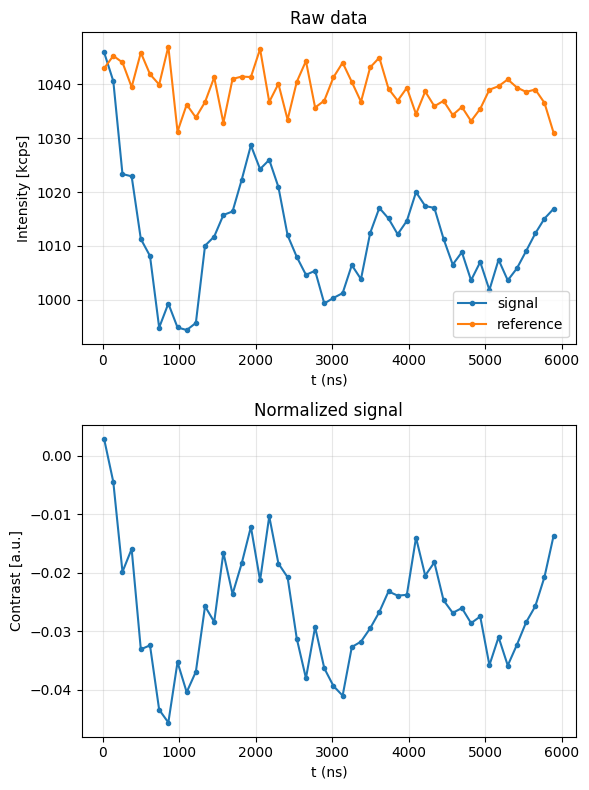

In [15]:
fig, ax = plt.subplots(2, 1, figsize=(6, 8))

ax[0].plot(t_ns, signal_kcps, 'o-', ms=3, label='signal')
ax[0].plot(t_ns, ref_kcps, 'o-', ms=3, label='reference')
ax[0].set_xlabel('t (ns)')
ax[0].set_ylabel('Intensity [kcps]')
ax[0].set_title('Raw data')
ax[0].grid(True, alpha=0.3)
ax[0].legend()

ax[1].plot(t_ns, normalized_data, 'o-', ms=3)
ax[1].set_xlabel('t (ns)')
ax[1].set_ylabel('Contrast [a.u.]')
ax[1].set_title('Normalized signal')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4) Fit


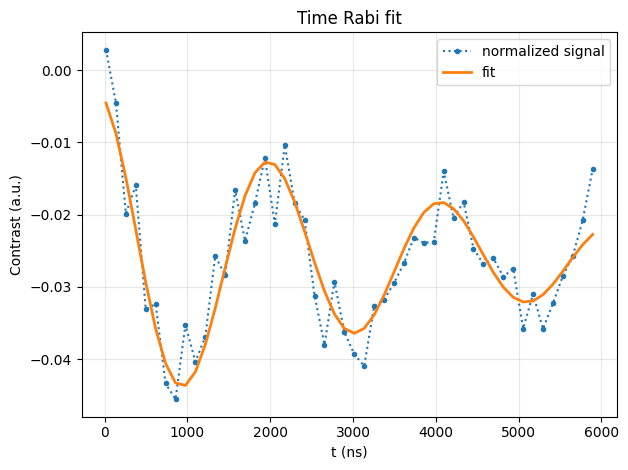

FitResult(decaying_cosine):
  amp                  = 0.0225937 ± 0.00244232
  freq                 = 0.000480715 ± 8.05626e-06
  phase                = 0.235885 ± 0.110152
  T                    = 3854.75 ± 753.197
  offset               = -0.0261267 ± 0.000641984

Derived times:
- period: 2080.237 ns
- t_pi (half-period): 1040.118 ns
- t_pi (phase-adjusted, first cos minimum): 962.022 ns


In [16]:
fitter = Fitter()
res = fitter.decaying_cosine(t_ns, normalized_data)

plt.figure(figsize=(6.4, 4.8))
plt.plot(res.x, res.y, ':o', ms=3, label='normalized signal')
plt.plot(res.x, res.y_fit, '-', lw=2, label='fit')
plt.xlabel('t (ns)')
plt.ylabel('Contrast (a.u.)')
plt.title('Time Rabi fit')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

freq  = res.params['freq']

print(res)

print('\nDerived times:')
if freq > 0:
    period_ns = 1.0 / freq
    t_pi_halfperiod_ns = 0.5 / freq
    phase = res.params['phase']
    t_pi_phase_ns = ((np.pi - phase) % (2.0 * np.pi)) / (2.0 * np.pi * freq)
    print(f'- period: {period_ns:.3f} ns')
    print(f'- t_pi (half-period): {t_pi_halfperiod_ns:.3f} ns')
    print(f'- t_pi (phase-adjusted, first cos minimum): {t_pi_phase_ns:.3f} ns')
else:
    print('Could not compute t_pi (missing/invalid freq).')